In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.gridspec import GridSpec

In [2]:
# Load the dataset
df = pd.read_csv('results/experiment_runs_log_users_actions_changes_only.csv')
df_experiment_details = pd.read_csv("results/experiment_runs_log_users_info_P7iwzVBKHYbSDrUWE.csv", header=0, usecols=range(10))

### Research question: Does AI-prediction correctness moderate the effect of explanations on participants’ accuracy?

In [3]:
def to_numeric_answer(value):
    """Convert answer values to numeric; invalid/missing values become NaN."""
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value in {"", "-", "None", "nan"}:
        return np.nan

    try:
        return int(float(value))
    except (TypeError, ValueError):
        return np.nan


# Keep only actual question rows
trials = df[df["param1"].isin(["LLM", "OS"])].copy()

answer_columns = [
    "trueShapeChoiceIndex",
    "predictedShapeChoiceIndex",
    "lInd_0_BeforeAi",
    "lInd_1_AfterAi",
    "lInd_2_AfterXai"
]

for column in answer_columns:
    trials[column] = trials[column].apply(to_numeric_answer)


# Extract a stable question ID, such as LLM_1228 or OS_218
trials["question_id"] = (
    trials["objectLogName"]
    .astype(str)
    .str.extract(r"((?:LLM|OS)_\d+)", expand=False)
)


# Use only trials containing both Stage 2 and Stage 3 responses
required_columns = [
    "tuid",
    "question_id",
    "trueShapeChoiceIndex",
    "predictedShapeChoiceIndex",
    "lInd_0_BeforeAi",
    "lInd_1_AfterAi",
    "lInd_2_AfterXai"
]

trials = trials.dropna(subset=required_columns).copy()


# If the log contains multiple snapshots of the same trial,
# retain the last complete snapshot
rows_before_deduplication = len(trials)

trials = (
    trials
    .sort_index()
    .drop_duplicates(subset=["tuid", "question_id"], keep="last")
)

print("Rows before deduplication:", rows_before_deduplication)
print("Complete paired trials:", len(trials))
print("Participants:", trials["tuid"].nunique())
print("Questions:", trials["question_id"].nunique())


# Variables for the analysis
trials["explanation_type"] = trials["param1"]

trials["ai_correct"] = (
    trials["predictedShapeChoiceIndex"]
    == trials["trueShapeChoiceIndex"]
).astype(int)

trials["before_correct"] = (
    trials["lInd_0_BeforeAi"]
    == trials["trueShapeChoiceIndex"]
).astype(int)

trials["after_prediction_correct"] = (
    trials["lInd_1_AfterAi"]
    == trials["trueShapeChoiceIndex"]
).astype(int)

trials["after_explanation_correct"] = (
    trials["lInd_2_AfterXai"]
    == trials["trueShapeChoiceIndex"]
).astype(int)


# Did the explanation correct or damage the participant's answer?
trials["explanation_recovered_error"] = (
    (trials["after_prediction_correct"] == 0)
    & (trials["after_explanation_correct"] == 1)
).astype(int)

trials["explanation_introduced_error"] = (
    (trials["after_prediction_correct"] == 1)
    & (trials["after_explanation_correct"] == 0)
).astype(int)

Rows before deduplication: 207
Complete paired trials: 206
Participants: 27
Questions: 16


In [4]:
def create_descriptive_table(data, group_columns):
    result = (
        data
        .groupby(group_columns, observed=True)
        .agg(
            n_trials=("tuid", "size"),
            accuracy_after_prediction=("after_prediction_correct", "mean"),
            accuracy_after_explanation=("after_explanation_correct", "mean"),
            recovered_errors=("explanation_recovered_error", "sum"),
            introduced_errors=("explanation_introduced_error", "sum")
        )
        .reset_index()
    )

    result["accuracy_after_prediction"] *= 100
    result["accuracy_after_explanation"] *= 100

    result["explanation_change_pp"] = (
        result["accuracy_after_explanation"]
        - result["accuracy_after_prediction"]
    )

    return result


# Overall, separated only by whether the AI was correct
overall_description = create_descriptive_table(
    trials,
    ["ai_correct"]
)

overall_description["ai_prediction"] = overall_description["ai_correct"].map({
    0: "AI prediction incorrect",
    1: "AI prediction correct"
})

display(
    overall_description[
        [
            "ai_prediction",
            "n_trials",
            "accuracy_after_prediction",
            "accuracy_after_explanation",
            "explanation_change_pp",
            "recovered_errors",
            "introduced_errors"
        ]
    ].round(2)
)


# Separate results for LLM and OS explanations
description_by_type = create_descriptive_table(
    trials,
    ["explanation_type", "ai_correct"]
)

description_by_type["ai_prediction"] = description_by_type["ai_correct"].map({
    0: "Incorrect",
    1: "Correct"
})

display(
    description_by_type[
        [
            "explanation_type",
            "ai_prediction",
            "n_trials",
            "accuracy_after_prediction",
            "accuracy_after_explanation",
            "explanation_change_pp",
            "recovered_errors",
            "introduced_errors"
        ]
    ].round(2)
)

,ai_prediction,n_trials,accuracy_after_prediction,accuracy_after_explanation,explanation_change_pp,recovered_errors,introduced_errors
0,AI prediction incorrect,98,33.67,33.67,0.00,4,4
1,AI prediction correct,108,64.81,62.04,-2.78,8,11


,explanation_type,ai_prediction,n_trials,accuracy_after_prediction,accuracy_after_explanation,explanation_change_pp,recovered_errors,introduced_errors
0,LLM,Incorrect,50,34.00,30.00,-4.00,2,4
1,LLM,Correct,53,77.36,67.92,-9.43,3,8
2,OS,Incorrect,48,33.33,37.50,4.17,2,0
3,OS,Correct,55,52.73,56.36,3.64,5,3


In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Convert each trial into two rows:
# Stage 2 = after prediction
# Stage 3 = after explanation
after_prediction = trials.copy()
after_prediction["stage"] = 0
after_prediction["team_correct"] = (
    after_prediction["after_prediction_correct"]
)

after_explanation = trials.copy()
after_explanation["stage"] = 1
after_explanation["team_correct"] = (
    after_explanation["after_explanation_correct"]
)

long_df = pd.concat(
    [after_prediction, after_explanation],
    ignore_index=True
)

long_df["explanation_type"] = pd.Categorical(
    long_df["explanation_type"],
    categories=["LLM", "OS"]
)


# Main model:
# The critical term is stage:ai_correct
#
# It tests whether the change from Stage 2 to Stage 3 differs
# when the AI prediction is correct versus incorrect.
moderation_model = smf.gee(
    formula=(
        "team_correct ~ "
        "stage * ai_correct + "
        "stage * C(explanation_type) + "
        "ai_correct * C(explanation_type) + "
        "before_correct"
    ),
    groups="tuid",
    data=long_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()

print(moderation_model.summary())

                               GEE Regression Results                              
Dep. Variable:                team_correct   No. Observations:                  412
Model:                                 GEE   No. clusters:                       27
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                  20
Family:                           Binomial   Mean cluster size:                15.3
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Wed, 12 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         14:31:39
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                         

In [6]:
term = "stage:ai_correct"

coefficient = moderation_model.params[term]
p_value = moderation_model.pvalues[term]
ci_low, ci_high = moderation_model.conf_int().loc[term]

odds_ratio = np.exp(coefficient)
or_ci_low = np.exp(ci_low)
or_ci_high = np.exp(ci_high)

print("Critical Stage × AI-correctness interaction")
print(f"Coefficient: {coefficient:.3f}")
print(f"Odds ratio: {odds_ratio:.3f}")
print(f"95% CI for OR: [{or_ci_low:.3f}, {or_ci_high:.3f}]")
print(f"p-value: {p_value:.4f}")

Critical Stage × AI-correctness interaction
Coefficient: -0.188
Odds ratio: 0.828
95% CI for OR: [0.369, 1.859]
p-value: 0.6481


In [7]:
full_model = smf.gee(
    formula=(
        "team_correct ~ "
        "stage * ai_correct * C(explanation_type) + "
        "before_correct"
    ),
    groups="tuid",
    data=long_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()

print(full_model.summary())

print("\nWald tests:")
print(full_model.wald_test_terms())

                               GEE Regression Results                              
Dep. Variable:                team_correct   No. Observations:                  412
Model:                                 GEE   No. clusters:                       27
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                  20
Family:                           Binomial   Mean cluster size:                15.3
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Wed, 12 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         14:31:39
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept             

/Users/ruti/.pyenv/versions/3.10.12/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [8]:
from scipy.stats import wilcoxon


participant_results = (
    trials
    .groupby(["tuid", "ai_correct"], observed=True)
    .agg(
        accuracy_after_prediction=(
            "after_prediction_correct",
            "mean"
        ),
        accuracy_after_explanation=(
            "after_explanation_correct",
            "mean"
        )
    )
    .reset_index()
)

participant_results["explanation_change"] = (
    participant_results["accuracy_after_explanation"]
    - participant_results["accuracy_after_prediction"]
)


def safe_wilcoxon(before, after):
    before = np.asarray(before, dtype=float)
    after = np.asarray(after, dtype=float)

    valid = ~(np.isnan(before) | np.isnan(after))
    before = before[valid]
    after = after[valid]

    differences = after - before

    if len(differences) == 0:
        return np.nan, np.nan, 0

    if np.allclose(differences, 0):
        return 0.0, 1.0, len(differences)

    statistic, p_value = wilcoxon(
        before,
        after,
        alternative="two-sided"
    )

    return statistic, p_value, len(differences)


for ai_value, label in [
    (0, "AI prediction incorrect"),
    (1, "AI prediction correct")
]:
    subset = participant_results[
        participant_results["ai_correct"] == ai_value
    ]

    statistic, p_value, n = safe_wilcoxon(
        subset["accuracy_after_prediction"],
        subset["accuracy_after_explanation"]
    )

    print(f"\n{label}")
    print(f"Participants: {n}")
    print(f"Wilcoxon statistic: {statistic}")
    print(f"p-value: {p_value:.4f}")


AI prediction incorrect
Participants: 26
Wilcoxon statistic: 13.5
p-value: 0.9314

AI prediction correct
Participants: 27
Wilcoxon statistic: 39.5
p-value: 0.6715


In [9]:
change_wide = participant_results.pivot(
    index="tuid",
    columns="ai_correct",
    values="explanation_change"
)

change_wide = change_wide.dropna(subset=[0, 1])

moderation_difference = (
    change_wide[1] - change_wide[0]
)

if np.allclose(moderation_difference, 0):
    interaction_statistic = 0.0
    interaction_p = 1.0
else:
    interaction_statistic, interaction_p = wilcoxon(
        moderation_difference,
        alternative="two-sided"
    )

print("Participant-level moderation test")
print(f"Participants with both AI outcome types: {len(change_wide)}")
print(f"Wilcoxon statistic: {interaction_statistic}")
print(f"p-value: {interaction_p:.4f}")

Participant-level moderation test
Participants with both AI outcome types: 26
Wilcoxon statistic: 53.0
p-value: 0.4249


# Analyze correct answers for payment/success

In [10]:
def xai_helped(pred, true, before_ai, after_ai, after_xai):
    # return after_ai != true and after_xai == true and pred == true
    return after_ai != true and after_xai == true

def xai_harmed(pred, true, before_ai, after_ai, after_xai):
    # return after_ai == true and after_xai != true and pred == true
    return after_ai == true and after_xai != true 

def xai_no_influence(pred, true, before_ai, after_ai, after_xai):
    return (after_ai == true and after_xai == true) or (after_ai != true and after_xai != true) or (after_ai == after_xai)

def ai_helped(pred, true, before_ai, after_ai, after_xai):
    # return before_ai != true and after_ai == true and pred == true
    return before_ai != true and after_ai == true

def ai_harmed(pred, true, before_ai, after_ai, after_xai):
    # return before_ai == true and after_ai != true and pred != true
    return before_ai == true and after_ai != true

def ai_no_influence(pred, true, before_ai, after_ai, after_xai):
    return (before_ai != true and after_ai != true) or (before_ai==true and after_ai==true)

In [11]:
def convert_2_int(num):
    if pd.isna(num) or num == '-':
        return None
    return int(num)

def analysis_test_results(users, users_logs):
    users_test_results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        correct_count = 0
        ai_helped_count = 0
        ai_harmed_count = 0
        ai_no_influence_count = 0

        xai_helped_count = 0
        xai_harmed_count = 0
        xai_no_influence_count = 0
        
        questions_num = 0

        correct_before_ai = {
         'LLM': 0,
          'OS': 0
        }
        correct_after_ai = {
         'LLM': 0,
          'OS': 0
        }
        correct_after_xai = {
         'LLM': 0,
          'OS': 0
        }
        questions_3_stages = {
         'correct_pred_OS': 0,
         'incorrect_pred_OS': 0,
         'correct_pred_LLM': 0,
         'incorrect_pred_LLM': 0,
        }
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):

                questions_num += 1
                
                # Case 1: for payment only
                if before_ai == pred_choice == true_choice or after_xai == true_choice:
                    correct_count += 1

                if pd.notna(before_ai) and pd.notna(after_ai) and pd.notna(after_xai):
                    if before_ai == true_choice:
                        correct_before_ai[explanation_type] += 1
                    if after_ai == true_choice:
                        correct_after_ai[explanation_type] += 1
                    if after_xai == true_choice:
                        correct_after_xai[explanation_type] += 1
                    if pred_choice == true_choice:
                        questions_3_stages[f'correct_pred_{explanation_type}'] += 1
                    else: 
                        questions_3_stages[f'incorrect_pred_{explanation_type}'] += 1

                ai_helped_count += ai_helped(pred_choice, true_choice, before_ai, after_ai, after_xai)
                ai_harmed_count += ai_harmed(pred_choice, true_choice, before_ai, after_ai, after_xai)
                ai_no_influence_count += ai_no_influence(pred_choice, true_choice, before_ai, after_ai, after_xai)
                
                xai_helped_count += xai_helped(pred_choice, true_choice, before_ai, after_ai, after_xai)
                xai_harmed_count += xai_harmed(pred_choice, true_choice, before_ai, after_ai, after_xai)
                xai_no_influence_count += xai_no_influence(pred_choice, true_choice, before_ai, after_ai, after_xai)


        users_test_results[user] = {
            "correct": correct_count,
            "ai_helped_count": ai_helped_count,
            "ai_harmed_count": ai_harmed_count,
            "ai_no_influence_count": ai_no_influence_count,
            "xai_helped_count": xai_helped_count,
            "xai_harmed_count": xai_harmed_count,
            "xai_no_influence_count": xai_no_influence_count,
            "questions_num": questions_num,
            "before_ai_success": correct_before_ai,
            "after_ai_success": correct_after_ai,
            "after_xai_success": correct_after_xai,
            "questions_3_stages": questions_3_stages
        }

    return users_test_results

In [12]:
# users = set(df['tuid'])
users = set(df['tuid'])
results = analysis_test_results(users, df)
results

{'UID_mz88Xt41La41zr36kB': {'correct': 5,
  'ai_helped_count': 0,
  'ai_harmed_count': 1,
  'ai_no_influence_count': 11,
  'xai_helped_count': 3,
  'xai_harmed_count': 1,
  'xai_no_influence_count': 8,
  'questions_num': 12,
  'before_ai_success': {'LLM': 1, 'OS': 1},
  'after_ai_success': {'LLM': 1, 'OS': 1},
  'after_xai_success': {'LLM': 1, 'OS': 3},
  'questions_3_stages': {'correct_pred_OS': 5,
   'incorrect_pred_OS': 2,
   'correct_pred_LLM': 1,
   'incorrect_pred_LLM': 3}},
 'UID_Vl48Oi40Lt34vN69pb': {'correct': 10,
  'ai_helped_count': 3,
  'ai_harmed_count': 7,
  'ai_no_influence_count': 4,
  'xai_helped_count': 1,
  'xai_harmed_count': 0,
  'xai_no_influence_count': 13,
  'questions_num': 14,
  'before_ai_success': {'LLM': 1, 'OS': 0},
  'after_ai_success': {'LLM': 2, 'OS': 1},
  'after_xai_success': {'LLM': 2, 'OS': 2},
  'questions_3_stages': {'correct_pred_OS': 1,
   'incorrect_pred_OS': 2,
   'correct_pred_LLM': 2,
   'incorrect_pred_LLM': 2}},
 'UID_ml46KH20Ef19wE69ad': 

In [13]:
# for user in results:
#     print(f"{user}: {results[user]['questions_num']}")
len(results)

27

## graph: A dual-axis "Performance vs. Confidence" line graph
X-axis: "Reveal Stages" (1, 2, 3).

Primary Y-axis (Left): "Objective Accuracy (%)"

Secondary Y-axis: "Subjective Confidence"

In [14]:
def get_success_and_confidence_each_stage(users, users_logs):
    totals = {
        'LLM': {
            'before_ok': 0, 'after_ai_ok': 0, 'after_xai_ok': 0,
            'before_n': 0,  'after_ai_n': 0,  'after_xai_n': 0,
            'conf_before_sum': 0, 'conf_after_ai_sum': 0, 'conf_after_xai_sum': 0,
            'conf_before_n': 0,   'conf_after_ai_n': 0,   'conf_after_xai_n': 0,
        },
        'OS':  {
            'before_ok': 0, 'after_ai_ok': 0, 'after_xai_ok': 0,
            'before_n': 0,  'after_ai_n': 0,  'after_xai_n': 0,
            'conf_before_sum': 0, 'conf_after_ai_sum': 0, 'conf_after_xai_sum': 0,
            'conf_before_n': 0,   'conf_after_ai_n': 0,   'conf_after_xai_n': 0,
        },
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        for _, row in user_data.iterrows():
            explanation_type = row.get('param1')
            if explanation_type not in ('LLM', 'OS'):
                continue

            true_choice = convert_2_int(row.get('trueShapeChoiceIndex'))
            if pd.isna(true_choice):
                continue

            before_ai = convert_2_int(row.get('lInd_0_BeforeAi'))
            after_ai  = convert_2_int(row.get('lInd_1_AfterAi'))
            after_xai = convert_2_int(row.get('lInd_2_AfterXai'))

            conf_before = convert_2_int(row.get('face_0_BeforeAi'))
            conf_after  = convert_2_int(row.get('face_1_AfterAi'))
            conf_xai    = convert_2_int(row.get('face_2_AfterXai'))

            cur = totals[explanation_type]

            # Stage 1: accuracy + confidence
            if pd.notna(before_ai):
                cur['before_n'] += 1
                if before_ai == true_choice:
                    cur['before_ok'] += 1
            if pd.notna(conf_before):
                cur['conf_before_n'] += 1
                cur['conf_before_sum'] += conf_before

            # Stage 2
            if pd.notna(after_ai):
                cur['after_ai_n'] += 1
                if after_ai == true_choice:
                    cur['after_ai_ok'] += 1
            if pd.notna(conf_after):
                cur['conf_after_ai_n'] += 1
                cur['conf_after_ai_sum'] += conf_after

            # Stage 3
            if pd.notna(after_xai):
                cur['after_xai_n'] += 1
                if after_xai == true_choice:
                    cur['after_xai_ok'] += 1
            if pd.notna(conf_xai):
                cur['conf_after_xai_n'] += 1
                cur['conf_after_xai_sum'] += conf_xai

   # compute means at the end
    for t in ('LLM', 'OS'):
        cur = totals[t]
        cur['conf_before_mean']  = (cur['conf_before_sum']  / cur['conf_before_n'])  if cur['conf_before_n']  else float('nan')
        cur['conf_after_ai_mean'] = (cur['conf_after_ai_sum'] / cur['conf_after_ai_n']) if cur['conf_after_ai_n'] else float('nan')
        cur['conf_after_xai_mean'] = (cur['conf_after_xai_sum'] / cur['conf_after_xai_n']) if cur['conf_after_xai_n'] else float('nan')
    return totals

def add_overall_totals(totals):
    llm = totals['LLM']
    os_ = totals['OS']

    overall = {}

    # accuracy counts
    for k in ['before_ok','after_ai_ok','after_xai_ok','before_n','after_ai_n','after_xai_n']:
        overall[k] = llm.get(k, 0) + os_.get(k, 0)

    # confidence sums + ns
    for k in ['conf_before_sum','conf_after_ai_sum','conf_after_xai_sum',
              'conf_before_n','conf_after_ai_n','conf_after_xai_n']:
        overall[k] = llm.get(k, 0) + os_.get(k, 0)

    # confidence means
    overall['conf_before_mean'] = (overall['conf_before_sum'] / overall['conf_before_n']) if overall['conf_before_n'] else float('nan')
    overall['conf_after_ai_mean'] = (overall['conf_after_ai_sum'] / overall['conf_after_ai_n']) if overall['conf_after_ai_n'] else float('nan')
    overall['conf_after_xai_mean'] = (overall['conf_after_xai_sum'] / overall['conf_after_xai_n']) if overall['conf_after_xai_n'] else float('nan')

    totals['OVERALL'] = overall
    return totals

In [15]:
result_per_stage = get_success_and_confidence_each_stage(users, df)
result_per_stage = add_overall_totals(result_per_stage)
result_per_stage

{'LLM': {'before_ok': 64,
  'after_ai_ok': 58,
  'after_xai_ok': 51,
  'before_n': 157,
  'after_ai_n': 103,
  'after_xai_n': 103,
  'conf_before_sum': 566,
  'conf_after_ai_sum': 369,
  'conf_after_xai_sum': 394,
  'conf_before_n': 157,
  'conf_after_ai_n': 103,
  'conf_after_xai_n': 103,
  'conf_before_mean': 3.605095541401274,
  'conf_after_ai_mean': 3.5825242718446604,
  'conf_after_xai_mean': 3.825242718446602},
 'OS': {'before_ok': 48,
  'after_ai_ok': 45,
  'after_xai_ok': 50,
  'before_n': 146,
  'after_ai_n': 104,
  'after_xai_n': 104,
  'conf_before_sum': 544,
  'conf_after_ai_sum': 378,
  'conf_after_xai_sum': 395,
  'conf_before_n': 146,
  'conf_after_ai_n': 104,
  'conf_after_xai_n': 104,
  'conf_before_mean': 3.7260273972602738,
  'conf_after_ai_mean': 3.6346153846153846,
  'conf_after_xai_mean': 3.798076923076923},
 'OVERALL': {'before_ok': 112,
  'after_ai_ok': 103,
  'after_xai_ok': 101,
  'before_n': 303,
  'after_ai_n': 207,
  'after_xai_n': 207,
  'conf_before_sum':

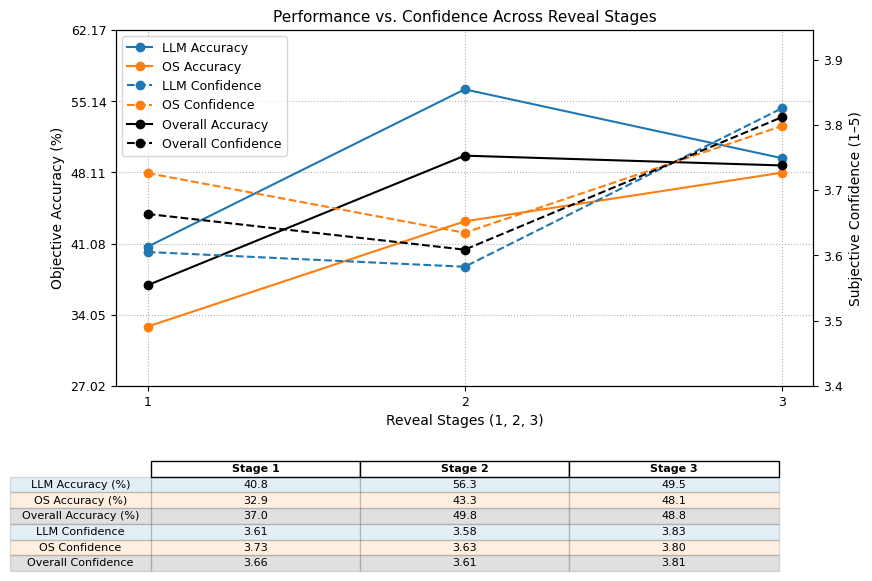

In [16]:
def plot_performance_vs_confidence(totals):
    stages = [1, 2, 3]

    def acc_pct(d, ok_key, n_key):
        return (d[ok_key] / d[n_key] * 100) if d[n_key] else float('nan')

    def finite_vals(arr):
        return [v for v in arr if v == v]  # NaN filter

    llm = totals['LLM']
    os_ = totals['OS']
    overall = totals.get('OVERALL')  # after add_overall_totals

    llm_acc = [
        acc_pct(llm, 'before_ok', 'before_n'),
        acc_pct(llm, 'after_ai_ok', 'after_ai_n'),
        acc_pct(llm, 'after_xai_ok', 'after_xai_n'),
    ]
    os_acc = [
        acc_pct(os_, 'before_ok', 'before_n'),
        acc_pct(os_, 'after_ai_ok', 'after_ai_n'),
        acc_pct(os_, 'after_xai_ok', 'after_xai_n'),
    ]

    llm_conf = [llm['conf_before_mean'], llm['conf_after_ai_mean'], llm['conf_after_xai_mean']]
    os_conf  = [os_['conf_before_mean'],  os_['conf_after_ai_mean'],  os_['conf_after_xai_mean']]

    overall_acc = [np.nan, np.nan, np.nan]
    overall_conf = [np.nan, np.nan, np.nan]
    if overall is not None:
        overall_acc = [
            acc_pct(overall, 'before_ok', 'before_n'),
            acc_pct(overall, 'after_ai_ok', 'after_ai_n'),
            acc_pct(overall, 'after_xai_ok', 'after_xai_n'),
        ]
        overall_conf = [overall['conf_before_mean'], overall['conf_after_ai_mean'], overall['conf_after_xai_mean']]

    # ---- Figure with dedicated table area below ----
    fig = plt.figure(figsize=(9, 6.8))
    gs = GridSpec(nrows=2, ncols=1, height_ratios=[4.3, 1.4], hspace=0.22)  # <- gap between plot & table
    ax1 = fig.add_subplot(gs[0])
    ax_tbl = fig.add_subplot(gs[1])
    ax_tbl.axis("off")

    # Accuracy (solid) - left axis
    line_llm_acc, = ax1.plot(stages, llm_acc, linestyle='-', marker='o', label='LLM Accuracy')
    line_os_acc,  = ax1.plot(stages, os_acc,  linestyle='-', marker='o', label='OS Accuracy')
    line_overall_acc, = ax1.plot(
        stages, overall_acc, linestyle='-', marker='o', label='Overall Accuracy', color='black'
    )

    ax1.set_xlabel('Reveal Stages (1, 2, 3)')
    ax1.set_ylabel('Objective Accuracy (%)')
    ax1.set_xticks(stages)
    ax1.grid(True, linestyle=':', linewidth=0.8)
    ax1.tick_params(axis='both', labelsize=9)

    # Confidence (dashed) - right axis
    ax2 = ax1.twinx()
    line_llm_conf, = ax2.plot(
        stages, llm_conf, linestyle='--', marker='o',
        label='LLM Confidence', color=line_llm_acc.get_color()
    )
    line_os_conf,  = ax2.plot(
        stages, os_conf, linestyle='--', marker='o',
        label='OS Confidence', color=line_os_acc.get_color()
    )
    line_overall_conf, = ax2.plot(
        stages, overall_conf, linestyle='--', marker='o',
        label='Overall Confidence', color='black'
    )

    ax2.set_ylabel('Subjective Confidence (1–5)')
    ax2.tick_params(axis='y', labelsize=9)

    # ---- Make Y ranges tighter (more separation visually) ----
    acc_all = finite_vals(llm_acc) + finite_vals(os_acc) + finite_vals(overall_acc)
    conf_all = finite_vals(llm_conf) + finite_vals(os_conf) + finite_vals(overall_conf)

    if acc_all:
        acc_min, acc_max = min(acc_all), max(acc_all)
        pad = max(3.0, (acc_max - acc_min) * 0.25)  # dynamic padding
        ax1.set_ylim(max(0, acc_min - pad), min(100, acc_max + pad))
        ax1.set_yticks(np.linspace(ax1.get_ylim()[0], ax1.get_ylim()[1], 6))

    if conf_all:
        conf_min, conf_max = min(conf_all), max(conf_all)
        pad = max(0.12, (conf_max - conf_min) * 0.35)
        lo = max(1, conf_min - pad)
        hi = min(5, conf_max + pad)
        ax2.set_ylim(lo, hi)
        # ticks every 0.1/0.2 depending on range
        step = 0.1 if (hi - lo) <= 0.6 else 0.2
        ax2.set_yticks(np.arange(np.floor(lo/step)*step, hi + 1e-9, step))

    # ---- Combined legend ----
    lines = [line_llm_acc, line_os_acc, line_llm_conf, line_os_conf, line_overall_acc, line_overall_conf]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=9)

    ax1.set_title('Performance vs. Confidence Across Reveal Stages', fontsize=11)

    # =========================
    # Table (bottom axis)
    # =========================
    def fmt_or_dash(v, fmt):
        return "—" if (v is None or (isinstance(v, float) and np.isnan(v))) else fmt.format(v)

    col_labels = ["Stage 1", "Stage 2", "Stage 3"]
    row_labels = [
        "LLM Accuracy (%)", "OS Accuracy (%)", "Overall Accuracy (%)",
        "LLM Confidence", "OS Confidence", "Overall Confidence"
    ]

    cell_text = [
        [fmt_or_dash(v, "{:.1f}") for v in llm_acc],
        [fmt_or_dash(v, "{:.1f}") for v in os_acc],
        [fmt_or_dash(v, "{:.1f}") for v in overall_acc],
        [fmt_or_dash(v, "{:.2f}") for v in llm_conf],
        [fmt_or_dash(v, "{:.2f}") for v in os_conf],
        [fmt_or_dash(v, "{:.2f}") for v in overall_conf],
    ]

    table = ax_tbl.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        rowLoc='center',
        bbox=[0.05, -0.15, 0.9, 0.95]  
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.25)

    # ---- Color table rows by corresponding plot colors ----
    row_colors = [
        line_llm_acc.get_color(),  # LLM Accuracy
        line_os_acc.get_color(),   # OS Accuracy
        'black',                   # Overall Accuracy
        line_llm_conf.get_color(), # LLM Confidence (same as LLM)
        line_os_conf.get_color(),  # OS Confidence (same as OS)
        'black'                    # Overall Confidence
    ]

    # Matplotlib table indexing:
    # header row is (0, col)
    # data rows start at 1..N
    # row label column is -1
    alpha = 0.12
    nrows = len(row_labels)
    ncols = len(col_labels)

    for r in range(1, nrows + 1):
        c = row_colors[r - 1]
        # color row-label cell
        if (r, -1) in table.get_celld():
            table[(r, -1)].set_facecolor(c)
            table[(r, -1)].set_alpha(alpha)
        # color each data cell
        for col in range(ncols):
            if (r, col) in table.get_celld():
                table[(r, col)].set_facecolor(c)
                table[(r, col)].set_alpha(alpha)

    # (optional) make header slightly bold
    for col in range(ncols):
        if (0, col) in table.get_celld():
            table[(0, col)].get_text().set_fontweight('bold')

    plt.savefig("performance_vs_confidence.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_performance_vs_confidence(result_per_stage)

In [17]:
totals = defaultdict(int)
nested_totals = defaultdict(lambda: defaultdict(int))

for stats in results.values():
    for key, value in stats.items():
        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                nested_totals[key][subkey] += subvalue
        else:
            totals[key] += value

# Print flat totals
print("🔹 Top-level totals:")
for key, value in totals.items():
    print(f"{key}: {value}")

# Print nested totals
print("\n🔹 Nested totals:")
for key, subdict in nested_totals.items():
    print(f"{key}:")
    success = 0
    for subkey, subvalue in subdict.items():
        print(f"  {subkey}: {subvalue}")
        success += subvalue
    print("  total success:", success)

🔹 Top-level totals:
correct: 178
ai_helped_count: 75
ai_harmed_count: 84
ai_no_influence_count: 144
xai_helped_count: 13
xai_harmed_count: 15
xai_no_influence_count: 275
questions_num: 303

🔹 Nested totals:
before_ai_success:
  LLM: 22
  OS: 13
  total success: 35
after_ai_success:
  LLM: 58
  OS: 45
  total success: 103
after_xai_success:
  LLM: 51
  OS: 50
  total success: 101
questions_3_stages:
  correct_pred_OS: 56
  incorrect_pred_OS: 48
  correct_pred_LLM: 53
  incorrect_pred_LLM: 50
  total success: 207


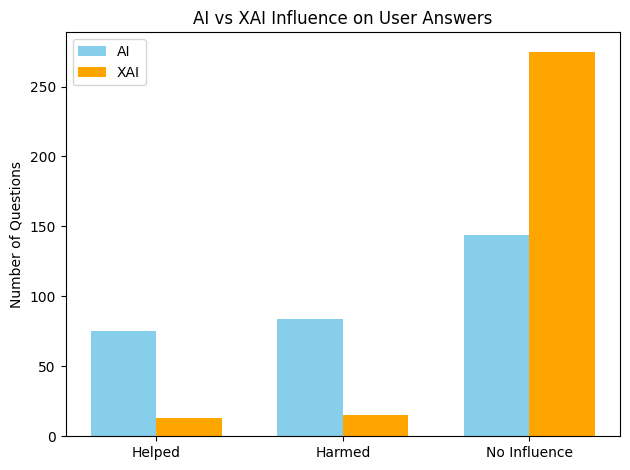

In [18]:
# Prepare data for plotting
categories = ['Helped', 'Harmed', 'No Influence']
ai_values = [totals['ai_helped_count'], totals['ai_harmed_count'], totals['ai_no_influence_count']]
xai_values = [totals['xai_helped_count'], totals['xai_harmed_count'], totals['xai_no_influence_count']]

x = np.arange(len(categories))  # the label locations
width = 0.35  # width of each bar

# Create plot
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, ai_values, width, label='AI', color='skyblue')
rects2 = ax.bar(x + width/2, xai_values, width, label='XAI', color='orange')

# Labels and layout
ax.set_ylabel('Number of Questions')
ax.set_title('AI vs XAI Influence on User Answers')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()

# Check the confidence

In [19]:
def confidence_2_num(confidence):
    if pd.isna(confidence) or confidence == '-':
        return 0

    return float(confidence)
    
def confidence_test(users, users_logs):
    results = {}
    total_llm_qeustions = 0
    total_os_questions = 0
    total_llm_confidence = 0
    total_os_confidence = 0

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        questions_LLM = 0
        questions_OS = 0

        # os params
        confidence_before_ai_os = 0
        before_ai_stages_os = 0
        
        confidence_after_ai_os = 0
        after_ai_stages_os = 0
        
        confidence_after_xai_os = 0
        after_xai_stages_os = 0

        # llm params
        confidence_before_ai_llm = 0
        before_ai_stages_llm = 0
        
        confidence_after_ai_llm = 0
        after_ai_stages_llm = 0
        
        confidence_after_xai_llm = 0
        after_xai_stages_llm = 0
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']
            confidence_0 = row['face_0_BeforeAi']
            confidence_1 = row['face_1_AfterAi']
            confidence_2 = row['face_2_AfterXai']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):

                if explanation_type == "OS":
                    questions_OS += 1

                    confidence_before_ai_os, before_ai_stages_os = (
                        confidence_before_ai_os + confidence_0, 
                        before_ai_stages_os + 1
                    )
                    
                    (conf := confidence_2_num(confidence_1))
                    confidence_after_ai_os, after_ai_stages_os = (
                        confidence_after_ai_os + conf, 
                        after_ai_stages_os + (conf != 0)
                    )

                    (conf := confidence_2_num(confidence_2))
                    confidence_after_xai_os, after_xai_stages_os = (
                        confidence_after_xai_os + conf, 
                        after_xai_stages_os + (conf != 0)
                    )
                    
                    
                else:
                    questions_LLM += 1
                    confidence_before_ai_llm, before_ai_stages_llm = (
                        confidence_before_ai_llm + confidence_0, 
                        before_ai_stages_llm + 1
                    )
                    
                    (conf := confidence_2_num(confidence_1))
                    confidence_after_ai_llm, after_ai_stages_llm = (
                        confidence_after_ai_llm + conf, 
                        after_ai_stages_llm + (conf != 0)
                    )

                    (conf := confidence_2_num(confidence_2))
                    confidence_after_xai_llm, after_xai_stages_llm = (
                        confidence_after_xai_llm + conf, 
                        after_xai_stages_llm + (conf != 0)
                    )
                

        results[user] = {
            "questions_LLM": questions_LLM,
            "questions_OS": questions_OS,
            # saved in this format: (total confidence, total stages for this confidence)
            "confidence_before_ai_os": (confidence_before_ai_os, before_ai_stages_os), 
            "confidence_after_ai_os": (confidence_after_ai_os, after_ai_stages_os), 
            "confidence_after_xai_os": (confidence_after_xai_os, after_xai_stages_os),
            "confidence_before_ai_llm": (confidence_before_ai_llm, before_ai_stages_llm), 
            "confidence_after_ai_llm": (confidence_after_ai_llm, after_ai_stages_llm), 
            "confidence_after_xai_llm": (confidence_after_xai_llm, after_xai_stages_llm),
        }

    return results

In [20]:
confidence_results = confidence_test(users, df)

In [21]:
confidence_results

{'UID_mz88Xt41La41zr36kB': {'questions_LLM': 5,
  'questions_OS': 7,
  'confidence_before_ai_os': (20.0, 7),
  'confidence_after_ai_os': (20.0, 7),
  'confidence_after_xai_os': (24.0, 7),
  'confidence_before_ai_llm': (19.0, 5),
  'confidence_after_ai_llm': (13.0, 4),
  'confidence_after_xai_llm': (15.0, 4)},
 'UID_Vl48Oi40Lt34vN69pb': {'questions_LLM': 6,
  'questions_OS': 8,
  'confidence_before_ai_os': (32.0, 8),
  'confidence_after_ai_os': (10.0, 3),
  'confidence_after_xai_os': (11.0, 3),
  'confidence_before_ai_llm': (25.0, 6),
  'confidence_after_ai_llm': (15.0, 4),
  'confidence_after_xai_llm': (18.0, 4)},
 'UID_ml46KH20Ef19wE69ad': {'questions_LLM': 6,
  'questions_OS': 7,
  'confidence_before_ai_os': (31.0, 7),
  'confidence_after_ai_os': (17.0, 4),
  'confidence_after_xai_os': (17.0, 4),
  'confidence_before_ai_llm': (23.0, 6),
  'confidence_after_ai_llm': (16.0, 4),
  'confidence_after_xai_llm': (16.0, 4)},
 'UID_fQ41dE04fP47pK90FA': {'questions_LLM': 7,
  'questions_OS': 6

In [22]:
# Separate totals for tuple values and scalar ints
totals = {}

for stats in confidence_results.values():
    for key, value in stats.items():
        if isinstance(value, tuple):
            if key not in totals:
                totals[key] = (0.0, 0)
            a, b = totals[key]
            x, y = value
            totals[key] = (a + x, b + y)
        else:
            if key not in totals:
                totals[key] = 0
            totals[key] += value

print(totals)

{'questions_LLM': 157, 'questions_OS': 146, 'confidence_before_ai_os': (544.0, 146), 'confidence_after_ai_os': (378.0, 104), 'confidence_after_xai_os': (395.0, 104), 'confidence_before_ai_llm': (566.0, 157), 'confidence_after_ai_llm': (369.0, 103), 'confidence_after_xai_llm': (394.0, 103)}


In [23]:
# Prepare processed output
rows = []
rows.append({
    'Explanation type': 'LLM',
    'Mean confidence before ai': f"{(totals['confidence_before_ai_llm'][0] / totals['confidence_before_ai_llm'][1]):.1f}",
    'Mean confidence after ai': f"{(totals['confidence_after_ai_llm'][0] / totals['confidence_after_ai_llm'][1]):.1f}",
    'Mean confidence after xai': f"{(totals['confidence_after_xai_llm'][0] / totals['confidence_after_xai_llm'][1]):.1f}",
    '# Questions': totals['questions_LLM'],
})
rows.append({
    'Explanation type': 'OS',
    'Mean confidence before ai': f"{(totals['confidence_before_ai_os'][0] / totals['confidence_before_ai_os'][1]):.1f}",
    'Mean confidence after ai': f"{(totals['confidence_after_ai_os'][0] / totals['confidence_after_ai_os'][1]):.1f}",
    'Mean confidence after xai': f"{(totals['confidence_after_xai_os'][0] / totals['confidence_after_xai_os'][1]):.1f}",
    '# Questions': totals['questions_OS'],
})

df_result = pd.DataFrame(rows)
df_result

,Explanation type,Mean confidence before ai,Mean confidence after ai,Mean confidence after xai,# Questions
0,LLM,3.6,3.6,3.8,157
1,OS,3.7,3.6,3.8,146


# Check accuracy by personal details

In [24]:
def get_users_details(df):
    users = {}
    
    for _, row in df.iterrows():
        
        ranodom_id = row['RandomTempUID']
    
        users[ranodom_id] = {
            # "name": row['Name'],
            "age": row['Age'],
            "gender": row['Gender'],
            "ai_experince": row['AIExperienceYears'],
            "explanation_type_preffered": row['ExplanationTypePreference'],
            "details_explanation_preffered": row['DetailsInExplanationPreference'],
        }

    return users

In [25]:
users_details = get_users_details(df_experiment_details)

In [26]:
users_details

{'UID_Sp59WX69Ls96IJ56yH': {'age': 28,
  'gender': 'male',
  'ai_experince': '3-4',
  'explanation_type_preffered': 'textual',
  'details_explanation_preffered': 'brief'},
 'UID_bv13An42XI68xl08lQ': {'age': 29,
  'gender': 'male',
  'ai_experince': '1-2',
  'explanation_type_preffered': 'visual',
  'details_explanation_preffered': 'brief'},
 'UID_zv91uL38jb94JM58Jd': {'age': 26,
  'gender': 'male',
  'ai_experince': '1-2',
  'explanation_type_preffered': 'visual',
  'details_explanation_preffered': 'brief'},
 'UID_ew60Nc39UF65Cn93Gi': {'age': 28,
  'gender': 'male',
  'ai_experince': '3-4',
  'explanation_type_preffered': 'textual',
  'details_explanation_preffered': 'detailed'},
 'UID_GC64QU46gM94GA17IQ': {'age': 28,
  'gender': 'male',
  'ai_experince': '3-4',
  'explanation_type_preffered': 'visual',
  'details_explanation_preffered': 'brief'},
 'UID_Gz29hR95Pg54Iw09AL': {'age': 28,
  'gender': 'male',
  'ai_experince': '1-2',
  'explanation_type_preffered': 'visual',
  'details_exp

In [27]:
def get_users_data(users_logs, group_id):
    users_data = users_logs[users_logs['param1'] == group_id]

    users_num = users_data['tuid'].unique()

    results = {}
    for user in users_num:

        user_rows = users_data[users_data['tuid'] == user]

        user_rows = user_rows.copy()  # Make an explicit copy to avoid chained assignment
        user_rows.loc[:, 'lInd_0_BeforeAi'] = pd.to_numeric(user_rows['lInd_0_BeforeAi'], errors='coerce')
        user_rows.loc[:, 'lInd_1_AfterAi'] = pd.to_numeric(user_rows['lInd_1_AfterAi'], errors='coerce')
        user_rows.loc[:, 'lInd_2_AfterXai'] = pd.to_numeric(user_rows['lInd_2_AfterXai'], errors='coerce')
        
        
        before_ai_correct_rows = user_rows[user_rows['trueShapeChoiceIndex'] == user_rows['lInd_0_BeforeAi']]
        before_ai_wrong_rows = user_rows[user_rows['trueShapeChoiceIndex'] != user_rows['lInd_0_BeforeAi']]
        
        after_ai_correct_rows = user_rows[
            ~pd.isna(user_rows['lInd_1_AfterAi']) &
            (user_rows['lInd_1_AfterAi'] != '-') &
            (user_rows['trueShapeChoiceIndex'] == user_rows['lInd_1_AfterAi'])
        ]
        
        after_ai_wrong_rows = user_rows[
            ~pd.isna(user_rows['lInd_1_AfterAi']) &
            (user_rows['lInd_1_AfterAi'] != '-') &
            (user_rows['trueShapeChoiceIndex'] != user_rows['lInd_1_AfterAi'])
        ]
    
        after_xai_correct_rows = user_rows[
            ~pd.isna(user_rows['lInd_2_AfterXai']) &
            (user_rows['lInd_2_AfterXai'] != '-') &
            (user_rows['trueShapeChoiceIndex'] == user_rows['lInd_2_AfterXai'])
        ]
        
        after_xai_wrong_rows = user_rows[
            ~pd.isna(user_rows['lInd_2_AfterXai']) &
            (user_rows['lInd_2_AfterXai'] != '-') &
            (user_rows['trueShapeChoiceIndex'] != user_rows['lInd_2_AfterXai'])
        ]
        
        results[user] = {
            'before_ai_correct_rows': len(before_ai_correct_rows),
            'before_ai_wrong_rows': len(before_ai_wrong_rows),
            'after_ai_correct_rows': len(after_ai_correct_rows),
            'after_ai_wrong_rows': len(after_ai_wrong_rows),
            'after_xai_correct_rows': len(after_xai_correct_rows),
            'after_xai_wrong_rows': len(after_xai_wrong_rows)
        } 

    return results

In [28]:
llm_data = get_users_data(df, 'LLM')
os_data = get_users_data(df, 'OS')
llm_data

{'UID_zv91uL38jb94JM58Jd': {'before_ai_correct_rows': 4,
  'before_ai_wrong_rows': 4,
  'after_ai_correct_rows': 2,
  'after_ai_wrong_rows': 2,
  'after_xai_correct_rows': 2,
  'after_xai_wrong_rows': 2},
 'UID_Sp59WX69Ls96IJ56yH': {'before_ai_correct_rows': 4,
  'before_ai_wrong_rows': 3,
  'after_ai_correct_rows': 2,
  'after_ai_wrong_rows': 2,
  'after_xai_correct_rows': 1,
  'after_xai_wrong_rows': 3},
 'UID_bv13An42XI68xl08lQ': {'before_ai_correct_rows': 3,
  'before_ai_wrong_rows': 3,
  'after_ai_correct_rows': 3,
  'after_ai_wrong_rows': 1,
  'after_xai_correct_rows': 3,
  'after_xai_wrong_rows': 1},
 'UID_ml46KH20Ef19wE69ad': {'before_ai_correct_rows': 2,
  'before_ai_wrong_rows': 4,
  'after_ai_correct_rows': 3,
  'after_ai_wrong_rows': 1,
  'after_xai_correct_rows': 3,
  'after_xai_wrong_rows': 1},
 'UID_ew60Nc39UF65Cn93Gi': {'before_ai_correct_rows': 1,
  'before_ai_wrong_rows': 4,
  'after_ai_correct_rows': 2,
  'after_ai_wrong_rows': 2,
  'after_xai_correct_rows': 2,
  'af

In [29]:
def get_success_per_group(group_data):
    before_ai_correct = 0
    before_ai_total = 0

    after_ai_correct = 0
    after_ai_total = 0

    after_xai_correct = 0
    after_xai_total = 0
    
    for user in group_data:
        before_ai_correct += group_data[user]['before_ai_correct_rows']
        before_ai_total += group_data[user]['before_ai_correct_rows'] + group_data[user]['before_ai_wrong_rows']
        
        after_ai_correct += group_data[user]['after_ai_correct_rows']
        after_ai_total += group_data[user]['after_ai_correct_rows'] + group_data[user]['after_ai_correct_rows']

        after_xai_correct += group_data[user]['after_xai_correct_rows']
        after_xai_total += group_data[user]['after_xai_correct_rows'] + group_data[user]['after_xai_wrong_rows']
    
    return before_ai_correct, before_ai_total, after_ai_correct, after_ai_total, after_xai_correct, after_xai_total
    
def get_table_results(groups):
    rows = []
    for group_id, data in groups.items():
    
        before_ai_correct, before_ai_total, after_ai_correct, after_ai_total, after_xai_correct, after_xai_total = get_success_per_group(data)
    
        row = {
            'Group': group_id,
            'Before AI correct answers': f"{before_ai_correct}/{before_ai_total}",
            'After AI correct answers': f"{after_ai_correct}/{after_ai_total}",
            'After XAI correct answers': f"{after_xai_correct}/{after_xai_total}",
        }
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    return df_result

### Check what was the accuracy in the gender groups

In [30]:
def divide_groups_by_gender(users_results, users_details):
    women = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('gender') == 'female'
    }
    men = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('gender') == 'male'
    }
    return women, men

In [31]:
women_llm, men_llm = divide_groups_by_gender(llm_data, users_details)
women_os, men_os = divide_groups_by_gender(os_data, users_details)

In [32]:
gender_table = get_table_results(groups = {
    'Female - LLM part': women_llm,
    'Male - LLM part': men_llm,
    'Female - OS part': women_os,
    'Male - OS part': men_os
})
gender_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Female - LLM part,23/52,19/38,17/30
1,Male - LLM part,41/105,39/78,34/73
2,Female - OS part,12/44,15/30,15/29
3,Male - OS part,36/102,30/60,35/75


### Check what was the accuracy in the ai experience groups

In [33]:
def divide_groups_by_ai_experience(users_results, users_details):
    ai_0_1 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '0-1'
    }
    ai_1_2 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '1-2'
    }
    ai_3_4 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '3-4'
    }
    ai_5 = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('ai_experince') == '5'
    }
    return ai_0_1, ai_1_2, ai_3_4, ai_5

In [34]:
ai_0_1_llm, ai_1_2_llm, ai_3_4_llm, ai_5_llm = divide_groups_by_ai_experience(llm_data, users_details)
ai_0_1_os, ai_1_2_os, ai_3_4_os, ai_5_os = divide_groups_by_ai_experience(os_data, users_details)

In [35]:
ai_experience_table = get_table_results(groups = {
    'LLM: AI Experience: 0-1 Years': ai_0_1_llm,
    'LLM: AI Experience: 1-2 Years': ai_1_2_llm,
    'LLM: AI Experience: 3–4 Years': ai_3_4_llm,
    'LLM: AI Experience: 5+ Years': ai_5_llm,
    'OS: AI Experience: 0-1 Years': ai_0_1_os,
    'OS: AI Experience: 1-2 Years': ai_1_2_os,
    'OS: AI Experience: 3–4 Years': ai_3_4_os,
    'OS: AI Experience: 5+ Years': ai_5_os,
})
ai_experience_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,LLM: AI Experience: 0-1 Years,12/28,12/24,11/19
1,LLM: AI Experience: 1-2 Years,44/108,38/76,34/68
2,LLM: AI Experience: 3–4 Years,8/21,8/16,6/16
3,LLM: AI Experience: 5+ Years,0/0,0/0,0/0
4,OS: AI Experience: 0-1 Years,7/30,8/16,10/22
5,OS: AI Experience: 1-2 Years,28/91,28/56,32/66
6,OS: AI Experience: 3–4 Years,13/25,9/18,8/16
7,OS: AI Experience: 5+ Years,0/0,0/0,0/0


## Check what was the accuracy in the ExplanationTypePreference groups

In [36]:
def divide_groups_by_explanation_type(users_results, users_details):
    visual = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('explanation_type_preffered') == 'visual'
    }
    textual = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('explanation_type_preffered') == 'textual'
    }
    return visual, textual

In [37]:
visual_llm, textual_llm = divide_groups_by_explanation_type(llm_data, users_details)
visual_os, textual_os = divide_groups_by_explanation_type(os_data, users_details)

In [38]:
explnation_type_table = get_table_results(groups = {
    'Visual explanation preffered (LLM part)': visual_llm,
    'Visual explanation preffered (OS part)': visual_os,

    'Textual explanation preffered (LLM part)': textual_llm,
    'Textual explanation preffered (OS part)': textual_os,
})
explnation_type_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Visual explanation preffered (LLM part),45/108,40/80,35/67
1,Visual explanation preffered (OS part),31/92,27/54,30/65
2,Textual explanation preffered (LLM part),19/49,18/36,16/36
3,Textual explanation preffered (OS part),17/54,18/36,20/39


### Check what was the accuracy in the DetailsInExplanationPreference groups

In [39]:
def divide_groups_by_details_explanation(users_results, users_details):
    detailed = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('details_explanation_preffered') == 'detailed'
    }
    brief = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('details_explanation_preffered') == 'brief'
    }
    return detailed, brief

In [40]:
detailed_llm, brief_llm = divide_groups_by_details_explanation(llm_data, users_details)
detailed_os, brief_os = divide_groups_by_details_explanation(os_data, users_details)

In [41]:
explnation_details_table = get_table_results(groups = {
    'Detailed explanation preffered (LLM part)': detailed_llm,
    'Detailed explanation preffered (OS part)': detailed_os,

    'Brief explanation preffered (LLM part)': brief_llm,
    'Brief explanation preffered (OS part)': brief_os,
})
explnation_details_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Detailed explanation preffered (LLM part),19/38,12/24,10/23
1,Detailed explanation preffered (OS part),15/36,8/16,9/20
2,Brief explanation preffered (LLM part),45/119,46/92,41/80
3,Brief explanation preffered (OS part),33/110,37/74,41/84


### Check what was the accuracy in the age groups

In [42]:
def divide_groups_by_age(users_results, users_details):
    age_25_minus = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('age') <= 25
    }
    age_25_plus = {
        user: users_results[user] | users_details[user]
        for user in users_results
        if users_details[user].get('age') > 25
    }
    return age_25_minus, age_25_plus

## calc avg. age and sd

In [43]:
def get_all_ages(users_results, users_details):
    ages = []
    for user in users_results:
        ages.append(users_details[user]['age'])
    return ages

In [44]:
# len(get_all_ages(os_data, users_details)) #-------------!!!!!!
get_all_ages(os_data, users_details)

[28,
 28,
 26,
 28,
 28,
 28,
 29,
 27,
 31,
 30,
 24,
 20,
 24,
 30,
 46,
 24,
 22,
 24,
 23,
 27,
 26,
 35,
 28,
 26,
 23,
 24,
 27]

In [45]:
age_25_minus_llm, age_25_plus_llm = divide_groups_by_age(llm_data, users_details)
age_25_minus_os, age_25_plus_os = divide_groups_by_age(os_data, users_details)

In [46]:
age_table = get_table_results(groups = {
    'Age <= 25 (LLM part)': age_25_minus_llm,
    'Age <= 25 (OS part)': age_25_minus_os,

    'Age > 25 (LLM part)': age_25_plus_llm,
    'Age > 25 (OS part)': age_25_plus_os,
})
age_table

,Group,Before AI correct answers,After AI correct answers,After XAI correct answers
0,Age <= 25 (LLM part),24/56,20/40,18/35
1,Age <= 25 (OS part),13/48,16/32,18/35
2,Age > 25 (LLM part),40/101,38/76,33/68
3,Age > 25 (OS part),35/98,29/58,32/69


## Check how the first block of explanation affected the user accuracy in the second block

In [47]:
def analysis_block_affect(users, users_logs):
    results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        correct_count = 0
        block2_question_amount = 0

        first_explanation_block = (next(user_data.iterrows())[1])['param1']
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            explanation_type = row['param1']

            # Filter the rows of explanaion second block 
            if pd.notna(explanation_type) and explanation_type != first_explanation_block:
                block2_question_amount += 1
                
                if before_ai == true_choice:
                    correct_count += 1

            results[user] = {
                "correct": correct_count,
                "block2_question_amount": block2_question_amount,
                "first_explanation": first_explanation_block, 
                "success": f"{(correct_count / block2_question_amount * 100):.1f}%" if block2_question_amount > 0 else "N/A"
            }
    return results            
                

In [48]:
block_results = analysis_block_affect(users, df)

In [49]:
block_results

{'UID_mz88Xt41La41zr36kB': {'correct': 2,
  'block2_question_amount': 5,
  'first_explanation': 'OS',
  'success': '40.0%'},
 'UID_Vl48Oi40Lt34vN69pb': {'correct': 4,
  'block2_question_amount': 8,
  'first_explanation': 'LLM',
  'success': '50.0%'},
 'UID_ml46KH20Ef19wE69ad': {'correct': 3,
  'block2_question_amount': 7,
  'first_explanation': 'LLM',
  'success': '42.9%'},
 'UID_fQ41dE04fP47pK90FA': {'correct': 3,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '50.0%'},
 'UID_ew60Nc39UF65Cn93Gi': {'correct': 3,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '50.0%'},
 'UID_By02ns11Lv64xM09IR': {'correct': 0,
  'block2_question_amount': 0,
  'first_explanation': 'OS',
  'success': 'N/A'},
 'UID_bv13An42XI68xl08lQ': {'correct': 2,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '33.3%'},
 'UID_xb17Ox51pV61Cj23td': {'correct': 2,
  'block2_question_amount': 6,
  'first_explanation': 'LLM',
  'success': '33.3%

In [50]:
# Initialize containers
llm_successes = [] # llm affected the success in block 2
os_successes = [] # os affected the success in block 2

# Collect success rates
for user_data in block_results.values():
    success_str = user_data['success']
    
    if success_str != "N/A":  # Ignore entries with no valid data
        success = float(success_str.strip('%'))
        if user_data['first_explanation'] == 'LLM':
            llm_successes.append(success)
        elif user_data['first_explanation'] == 'OS':
            os_successes.append(success)

# Compute means
llm_mean = sum(llm_successes) / len(llm_successes) if llm_successes else 0
os_mean = sum(os_successes) / len(os_successes) if os_successes else 0

print(f"LLM Mean Success Rate: {llm_mean:.1f}%")
print(f"OS Mean Success Rate: {os_mean:.1f}%")

LLM Mean Success Rate: 35.1%
OS Mean Success Rate: 30.3%


## Check the post hoc questions results

In [51]:
def analysis_post_hoc_explanation(users, users_logs):
    llm_qs_sum = {'q1': 0, 'q2': 0, 'q3': 0}
    os_qs_sum = {'q1': 0, 'q2': 0, 'q3': 0}
    
    llm_qs_count = {'q1': 0, 'q2': 0, 'q3': 0}
    os_qs_count = {'q1': 0, 'q2': 0, 'q3': 0}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        for _, row in user_data.iterrows():
            object_log_name = row['objectLogName']
            confidence_level = row['faceSelected']

            if object_log_name.endswith('_SubmitRatingBtn'):
                for q_type, qs_sum, qs_count in [('LLM', llm_qs_sum, llm_qs_count), ('OS', os_qs_sum, os_qs_count)]:
                    for i in range(1, 4):
                        key = f'q{i}'
                        if f'{q_type}_question_{i}' in object_log_name:
                            qs_sum[key] += confidence_level
                            qs_count[key] += 1
                            break

    return {
        'llm': {'sum': llm_qs_sum, 'count': llm_qs_count},
        'os': {'sum': os_qs_sum, 'count': os_qs_count}
    }

In [52]:
results = analysis_post_hoc_explanation(users, df)

[3.8846153846153846, 3.230769230769231, 3.3461538461538463] [2.6923076923076925, 2.3076923076923075, 2.576923076923077]


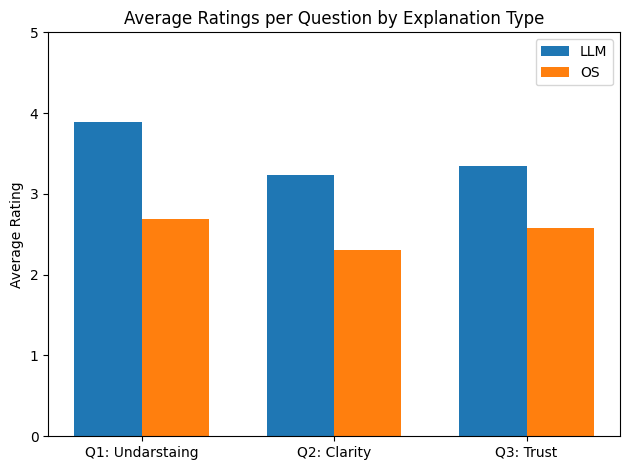

In [53]:
# Calculate averages
llm_means = [results['llm']['sum'][f'q{i}'] / results['llm']['count'][f'q{i}'] if results['llm']['count'][f'q{i}'] else 0 for i in range(1, 4)]
os_means = [results['os']['sum'][f'q{i}'] / results['os']['count'][f'q{i}'] if results['os']['count'][f'q{i}'] else 0 for i in range(1, 4)]
print(llm_means, os_means)

# Create bar plot
questions = ['Q1: Undarstaing', 'Q2: Clarity', 'Q3: Trust']
x = range(len(questions))
width = 0.35

fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], llm_means, width, label='LLM')
ax.bar([i + width/2 for i in x], os_means, width, label='OS')

ax.set_ylabel('Average Rating')
ax.set_title('Average Ratings per Question by Explanation Type')
ax.set_xticks(x)
ax.set_xticklabels(questions)
ax.set_ylim(0, 5)
ax.legend()

plt.tight_layout()
plt.show()

# Check how many users were right before the prediction

In [54]:
def right_before_ai(users, users_logs):
    questions_num = 0
    right_predictions = 0
    wrong_predictions = 0

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):
                if before_ai == true_choice:
                    questions_num += 1
                    
                    if true_choice == pred_choice:
                        right_predictions += 1
                    else:
                        wrong_predictions += 1

    return questions_num, right_predictions, wrong_predictions

In [55]:
questions_num, right_predictions, wrong_predictions = right_before_ai(users, df)

In [56]:
questions_num, right_predictions, wrong_predictions

(112, 77, 35)

# Check how many question with pred=true

In [57]:
def check_llm_os_questions(users, users_logs):
    llm_pred_true_match_count = 0
    os_pred_true_match_count = 0
    
    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ('LLM', 'OS'):
                if pred_choice == true_choice:
                    
                    if explanation_type == "OS":
                        os_pred_true_match_count += 1
                    else:
                        llm_pred_true_match_count += 1

    return os_pred_true_match_count, llm_pred_true_match_count

In [58]:
os, llm = check_llm_os_questions(users, df)

In [59]:
os, llm

(91, 95)

# Check what was the success % in the second block to those who xai helped them

In [60]:
results = analysis_test_results(users, df)

In [61]:
block_results = analysis_block_affect(users, df)

In [62]:
success_rate = 0
users_num = 0

for user in results:
    if results[user]['xai_helped_count'] > 0:
        users_num += 1

        success_str = block_results[user]['success']
        if success_str != "N/A":  # Ignore entries with no valid data
            success = float(success_str.strip('%'))
            success_rate += success

In [63]:
success_rate, users_num

(410.0, 11)

In [64]:
success_rate/users_num

37.27272727272727

# Testing the percentage of correct answers (before AI) in the first block compared to the second block

In [65]:
def analysis_block_success(users, users_logs):
    results = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]

        llm_correct_count = 0
        os_correct_count = 0
        os_questions = 0
        llm_questions = 0
        
        first_explanation_block = (next(user_data.iterrows())[1])['param1']
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            explanation_type = row['param1']

            # Filter the rows of explanaion second block 
            if pd.notna(explanation_type):
                if explanation_type == "LLM":
                    llm_questions += 1
                    
                    if before_ai == true_choice:
                        llm_correct_count += 1
                else:
                    os_questions += 1

                    if before_ai == true_choice:
                        os_correct_count += 1
                    

        results[user] = {
            "first_explanation": first_explanation_block,
            "llm_correct": llm_correct_count,
            "os_correct": os_correct_count,
            "llm_questions": llm_questions, 
            "os_questions": os_questions,
            "success_os": f"{(os_correct_count / os_questions * 100):.1f}%" if os_questions > 0 else "N/A",
            "success_llm": f"{(llm_correct_count / llm_questions * 100):.1f}%" if llm_questions > 0 else "N/A"
        }
    return results            

In [66]:
results = analysis_block_success(users, df)
results

{'UID_mz88Xt41La41zr36kB': {'first_explanation': 'OS',
  'llm_correct': 2,
  'os_correct': 1,
  'llm_questions': 5,
  'os_questions': 7,
  'success_os': '14.3%',
  'success_llm': '40.0%'},
 'UID_Vl48Oi40Lt34vN69pb': {'first_explanation': 'LLM',
  'llm_correct': 3,
  'os_correct': 4,
  'llm_questions': 6,
  'os_questions': 8,
  'success_os': '50.0%',
  'success_llm': '50.0%'},
 'UID_ml46KH20Ef19wE69ad': {'first_explanation': 'LLM',
  'llm_correct': 2,
  'os_correct': 3,
  'llm_questions': 6,
  'os_questions': 7,
  'success_os': '42.9%',
  'success_llm': '33.3%'},
 'UID_fQ41dE04fP47pK90FA': {'first_explanation': 'LLM',
  'llm_correct': 4,
  'os_correct': 3,
  'llm_questions': 7,
  'os_questions': 6,
  'success_os': '50.0%',
  'success_llm': '57.1%'},
 'UID_ew60Nc39UF65Cn93Gi': {'first_explanation': 'LLM',
  'llm_correct': 1,
  'os_correct': 3,
  'llm_questions': 5,
  'os_questions': 6,
  'success_os': '50.0%',
  'success_llm': '20.0%'},
 'UID_By02ns11Lv64xM09IR': {'first_explanation': 'O

In [67]:
llm_os_results = {
    "llm":{
        'llm_correct': 0,
        'os_correct': 0,
        'llm_questions': 0,
        'os_questions': 0,
    },
    "os": {
        'llm_correct': 0,
        'os_correct': 0,
        'llm_questions': 0,
        'os_questions': 0,
    }
}
os = 0
llm = 0
for user in results:
    explanation_type = results[user]['first_explanation'].lower()
    
    llm_os_results[explanation_type] = {
        'llm_correct': llm_os_results[explanation_type]['llm_correct']+results[user]['llm_correct'],
        'os_correct': llm_os_results[explanation_type]['os_correct']+results[user]['os_correct'],
        'llm_questions': llm_os_results[explanation_type]['llm_questions']+results[user]['llm_questions'],
        'os_questions': llm_os_results[explanation_type]['os_questions']+results[user]['os_questions'],
    }

In [68]:
llm_os_results

{'llm': {'llm_correct': 53,
  'os_correct': 41,
  'llm_questions': 123,
  'os_questions': 111},
 'os': {'llm_correct': 11,
  'os_correct': 7,
  'llm_questions': 34,
  'os_questions': 35}}

In [69]:
# when llm first explanation 
llm_first = (llm_os_results['llm']['llm_correct']/llm_os_results['llm']['llm_questions'] * 100) 
os_second = (llm_os_results['llm']['os_correct']/llm_os_results['llm']['os_questions'] * 100) 

# when os first explanation
os_first = (llm_os_results['os']['os_correct']/llm_os_results['os']['os_questions'] * 100) 
llm_second = (llm_os_results['os']['llm_correct']/llm_os_results['os']['llm_questions'] * 100)

print("When LLM was presented first:")
print(f"Correct answeres(before ai = true) in the LLM part:{llm_first:.1f}% and in the OS part: {os_second:.1f}%\n")
print("When OS was presented first:")
print(f"Correct answeres(before ai = true) in the OS part:{os_first:.1f}% and in the LLM part: {llm_second:.1f}%")

When LLM was presented first:
Correct answeres(before ai = true) in the LLM part:43.1% and in the OS part: 36.9%

When OS was presented first:
Correct answeres(before ai = true) in the OS part:20.0% and in the LLM part: 32.4%


### Calc total success in each explanation block

In [70]:
print(f"Success rate in llm part:{(llm_first+llm_second)/2:.1f}")
print(f"Success rate in os part:{(os_first+os_second)/2:.1f}")

Success rate in llm part:37.7
Success rate in os part:28.5


## Graphs - data

## graph 1

In [71]:
def check_accuracy_acording_to_ai(users, users_logs):
    users_test_results = {
        "LLM": {
            "before_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_xai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "total_pred_correct_questions": 0,
            "total_pred_incorrect_questions": 0,
        },
        "OS": {
            "before_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_ai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "after_xai": {
                "correct_answers": 0,
                "questions": 0,
                "correct_pred_questions": 0,
                "incorrect_pred_questions": 0,
            },
            "total_pred_correct_questions": 0,
            "total_pred_incorrect_questions": 0,
        }
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ("LLM", "OS"):

                # questions counter
                if pred_choice == true_choice:
                    users_test_results[explanation_type]["total_pred_correct_questions"] += 1
                else:
                    users_test_results[explanation_type]["total_pred_incorrect_questions"] += 1

                
                if pd.notna(before_ai) and after_ai == None and after_xai == None:
                    if before_ai == true_choice:
                        users_test_results[explanation_type]["before_ai"]["correct_answers"] += 1
                        
                        if pred_choice == true_choice:
                            users_test_results[explanation_type]["before_ai"]["correct_pred_questions"] += 1
                        else:
                            users_test_results[explanation_type]["before_ai"]["incorrect_pred_questions"] += 1
                        
                    users_test_results[explanation_type]["before_ai"]["questions"] += 1
                        
                elif pd.notna(before_ai) and pd.notna(after_ai) and pd.notna(after_xai):
                    users_test_results[explanation_type]["before_ai"]["questions"] += 1
                    users_test_results[explanation_type]["after_ai"]["questions"] += 1
                    users_test_results[explanation_type]["after_xai"]["questions"] += 1
                    
                    if before_ai == true_choice:
                        users_test_results[explanation_type]["before_ai"]["correct_answers"] += 1
                        category = "correct_pred_questions" if (pred_choice == true_choice) else "incorrect_pred_questions"
                        users_test_results[explanation_type]["before_ai"][category] += 1
                    if after_ai == true_choice:
                        users_test_results[explanation_type]["after_ai"]["correct_answers"] += 1
                        category = "correct_pred_questions" if (pred_choice == true_choice) else "incorrect_pred_questions"
                        users_test_results[explanation_type]["after_ai"][category] += 1
                    if after_xai == true_choice:
                        users_test_results[explanation_type]["after_xai"]["correct_answers"] += 1
                        category = "correct_pred_questions" if (pred_choice == true_choice) else "incorrect_pred_questions"
                        users_test_results[explanation_type]["after_xai"][category] += 1
    return users_test_results

In [72]:
users = set(df['tuid'])
success_rate = check_accuracy_acording_to_ai(users, df)

In [73]:
success_rate

{'LLM': {'before_ai': {'correct_answers': 64,
   'questions': 157,
   'correct_pred_questions': 42,
   'incorrect_pred_questions': 22},
  'after_ai': {'correct_answers': 58,
   'questions': 103,
   'correct_pred_questions': 41,
   'incorrect_pred_questions': 17},
  'after_xai': {'correct_answers': 51,
   'questions': 103,
   'correct_pred_questions': 36,
   'incorrect_pred_questions': 15},
  'total_pred_correct_questions': 95,
  'total_pred_incorrect_questions': 62},
 'OS': {'before_ai': {'correct_answers': 48,
   'questions': 146,
   'correct_pred_questions': 35,
   'incorrect_pred_questions': 13},
  'after_ai': {'correct_answers': 45,
   'questions': 104,
   'correct_pred_questions': 29,
   'incorrect_pred_questions': 16},
  'after_xai': {'correct_answers': 50,
   'questions': 104,
   'correct_pred_questions': 32,
   'incorrect_pred_questions': 18},
  'total_pred_correct_questions': 91,
  'total_pred_incorrect_questions': 55}}

## graph 2

In [74]:
def check_accuracy_acording_to_ai_prediction(users, users_logs):
    users_test_results = {
        "LLM": {
            "after_ai": {
                "matched_answers": 0,
                "questions": 0,
            },
            "after_xai": {
                "matched_answers": 0,
                "questions": 0,
            },
        },
        "OS": {
            "after_ai": {
                "matched_answers": 0,
                "questions": 0,
            },
            "after_xai": {
                "matched_answers": 0,
                "questions": 0,
            },
        }
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if explanation_type in ("LLM", "OS"):        
                if pd.notna(before_ai) and pd.notna(after_ai) and pd.notna(after_xai):
                    users_test_results[explanation_type]["after_ai"]["questions"] += 1
                    users_test_results[explanation_type]["after_xai"]["questions"] += 1
                    
                    if after_ai == pred_choice:
                        users_test_results[explanation_type]["after_ai"]["matched_answers"] += 1
                    if after_xai == pred_choice:
                        users_test_results[explanation_type]["after_xai"]["matched_answers"] += 1
    return users_test_results

In [75]:
accuracy_by_model_prediction = check_accuracy_acording_to_ai_prediction(users, df)

In [76]:
accuracy_by_model_prediction

{'LLM': {'after_ai': {'matched_answers': 55, 'questions': 103},
  'after_xai': {'matched_answers': 53, 'questions': 103}},
 'OS': {'after_ai': {'matched_answers': 40, 'questions': 104},
  'after_xai': {'matched_answers': 47, 'questions': 104}}}

# graph 3

In [77]:
def extract_question_num(s):
    last_parts = s.split('_')[-2:]
    if last_parts[-1].isdigit():
        result = last_parts[-1]
    else:
        result = "_".join(last_parts)
    return result

def check_questions_accuracy(users, users_logs):
    questions = {}

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            true_choice = convert_2_int(row['trueShapeChoiceIndex'])
            pred_choice = convert_2_int(row['predictedShapeChoiceIndex'])
            question = extract_question_num(row['blockId'])
            before_ai = convert_2_int(row['lInd_0_BeforeAi'])
            after_ai = convert_2_int(row['lInd_1_AfterAi'])
            after_xai = convert_2_int(row['lInd_2_AfterXai'])
            explanation_type = row['param1']
            is_correct_prediction = row['isCorrectPrediction']

            # Filter rows that contain question data
            if explanation_type in ("LLM", "OS"): 
                if question not in questions:
                    questions[question] = {
                        "correct_answers": 0,
                        "question_appearances": 0,
                        "is_correct_prediction": is_correct_prediction,
                        "explanation": explanation_type
                    }
                if before_ai == true_choice:
                    questions[question]["correct_answers"] += 1

                questions[question]["question_appearances"] += 1
                
    return questions

In [78]:
questions = check_questions_accuracy(users, df)

In [79]:
questions

{'6999': {'correct_answers': 5,
  'question_appearances': 17,
  'is_correct_prediction': 'yes',
  'explanation': 'OS'},
 '869': {'correct_answers': 7,
  'question_appearances': 17,
  'is_correct_prediction': 'yes',
  'explanation': 'OS'},
 '1228': {'correct_answers': 10,
  'question_appearances': 40,
  'is_correct_prediction': 'yes',
  'explanation': 'OS'},
 '6569': {'correct_answers': 12,
  'question_appearances': 20,
  'is_correct_prediction': 'yes',
  'explanation': 'LLM'},
 '7108': {'correct_answers': 2,
  'question_appearances': 17,
  'is_correct_prediction': 'no',
  'explanation': 'LLM'},
 '7788': {'correct_answers': 20,
  'question_appearances': 24,
  'is_correct_prediction': 'no',
  'explanation': 'LLM'},
 '219': {'correct_answers': 0,
  'question_appearances': 21,
  'is_correct_prediction': 'no',
  'explanation': 'LLM'},
 '128': {'correct_answers': 1,
  'question_appearances': 22,
  'is_correct_prediction': 'no',
  'explanation': 'OS'},
 '7029': {'correct_answers': 11,
  'ques

# graph 4

In [80]:
def check_post_questions_affect(users, users_logs):
    results = {
        "LLM": {"q_1": {}, "q_2": {}, "q_3": {}},
        "OS": {"q_1": {}, "q_2": {}, "q_3": {}}
    }

    for user in users:
        user_data = users_logs[users_logs["tuid"] == user]
        
        for _, row in user_data.iterrows():
            block_id = row['blockId']
            rate = convert_2_int(row['faceSelected'])
            explanation_type = row['param1']

            # Filter rows that contain question data
            if pd.isna(explanation_type):
                
                # Get the question number at the end
                number = block_id.split('_')[-1]
                
                # Get the explanation type
                explanation = block_id.split('_')[4]

                if results[explanation][f"q_{number}"] == {}:
                    results[explanation][f"q_{number}"] = {"1": 0, "2": 0, "3": 0, "4": 0, "5": 0}

                results[explanation][f"q_{number}"][str(rate)] += 1
                
    return results

In [81]:
post_questions_rate = check_post_questions_affect(users, df)

In [82]:
post_questions_rate

{'LLM': {'q_1': {'1': 0, '2': 1, '3': 7, '4': 12, '5': 6},
  'q_2': {'1': 2, '2': 6, '3': 4, '4': 12, '5': 2},
  'q_3': {'1': 3, '2': 3, '3': 5, '4': 12, '5': 3}},
 'OS': {'q_1': {'1': 6, '2': 5, '3': 9, '4': 3, '5': 3},
  'q_2': {'1': 8, '2': 8, '3': 6, '4': 2, '5': 2},
  'q_3': {'1': 3, '2': 11, '3': 7, '4': 4, '5': 1}}}